In [ ]:
import json
import numpy as np
import pandas as pd
from itertools import cycle

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, roc_curve, auc, f1_score, confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split
from sklearn.utils import class_weight

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

In [ ]:
expr = pd.read_table('gene_expression.txt', sep=' ')
labels = pd.read_csv('labels.csv', index_col=0)
confirmed_features = pd.read_csv('confirmed_features_detail.csv')

In [ ]:
confirmed_features.columns = ['ensembl_id', 'gene']

In [ ]:
expr = expr.T
expr.columns = expr.columns.to_list()
labels.columns = ['Class']

In [ ]:
expr.columns = [col.split('.')[0] for col in expr.columns]

In [ ]:
labels.index = expr.index

In [ ]:
labels = [1 if x == 'Primary solid Tumor' else 0 for x in labels['Class']]

In [ ]:
confirmedGenes = [
    "COL24A1",
    "RAD51",
    "CLSPN",
    "ECT2",
    "IQGAP3",
    "ARHGAP11A",
    "CCL23",
    "SNHG4",
    "PLK4",
    "DNAJC6",
    "BAIAP2L2",
    "PIF1",
    "FANCD2",
    "BUB1",
    "TMC7",
    "CENPI",
    "COL9A1",
    "COL25A1",
    "STRA6",
    "KIAA1841",
    "RANBP3L",
    "DIRAS2",
    "CREG2",
    "FANCB"
]

In [ ]:
ensemblIDs = confirmed_features.set_index('gene').loc[confirmedGenes]['ensembl_id'].reset_index(drop=True).to_list()

In [ ]:
expr = expr[ensemblIDs]

In [ ]:
expr.shape

(421, 24)

In [ ]:
labels = pd.DataFrame(labels, index=expr.index.to_list(), columns=['Class'])

In [ ]:
data = pd.concat([expr, labels], axis=1)

In [ ]:
data.shape

(421, 25)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train),
    y=y_train.values.reshape(-1)
)

class_weights = {i: class_weights[i] for i in range(len(class_weights))}
print(class_weights)

{0: 4.2, 1: 0.5675675675675675}


In [ ]:
model = RandomForestClassifier(class_weight=class_weights, random_state=42, n_jobs=-1)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight={0: 4.2, 1: 0.5675675675675675}, n_jobs=-1,
                       random_state=42)

In [ ]:
acc = accuracy_score(y_test, model.predict(X_test))
prec = precision_score(y_test, model.predict(X_test))
rec = recall_score(y_test, model.predict(X_test))
f1 = f1_score(y_test, model.predict(X_test))

In [ ]:
print('Accuracy: {:.2f}'.format(acc))
print('Precision: {:.2f}'.format(prec))
print('Recall: {:.2f}'.format(rec))
print('F1 Score: {:.2f}'.format(f1))

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [ ]:
conf_matrix_train = confusion_matrix(y_train, model.predict(X_train))
conf_matrix_test = confusion_matrix(y_test, model.predict(X_test))

In [ ]:
conf_matrix_train

array([[ 40,   0],
       [  0, 296]])

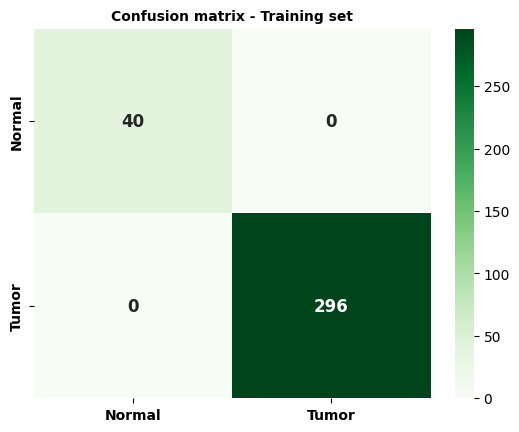

In [ ]:
ax= plt.subplot()
sns.heatmap(conf_matrix_train, annot=True, fmt='g', cmap='Greens', annot_kws={"weight": "bold", "size": 12},
            ax=ax)

ax.xaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
ax.yaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
plt.title('Confusion matrix - Training set', fontsize=10, weight='bold')
plt.savefig('confmatrix_train_confirmed.png', facecolor='w', dpi=200, bbox_inches='tight')

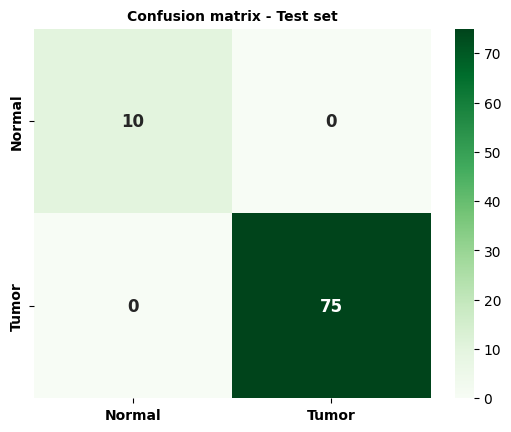

In [ ]:
ax= plt.subplot()
sns.heatmap(conf_matrix_test, annot=True, fmt='g', cmap='Greens', annot_kws={"weight": "bold", "size": 12},
            ax=ax)

ax.xaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
ax.yaxis.set_ticklabels(['Normal', 'Tumor'], weight='bold')
plt.title('Confusion matrix - Test set', fontsize=10, weight='bold')
plt.savefig('confmatrix_test_confirmed.png', facecolor='w', dpi=200, bbox_inches='tight')

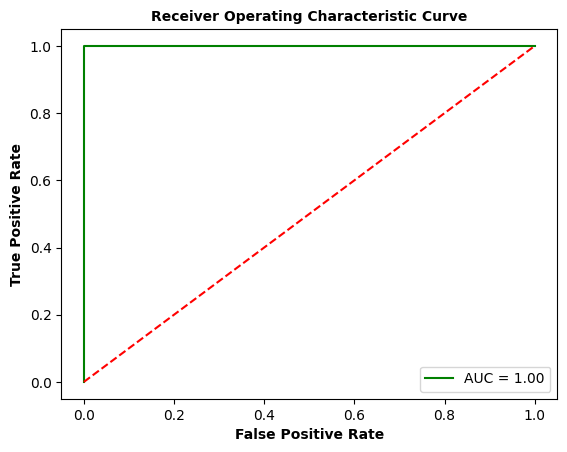

In [ ]:
probs = model.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic Curve', fontsize=10, weight='bold')
plt.plot(fpr, tpr, 'g', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.ylabel('True Positive Rate', weight='bold')
plt.xlabel('False Positive Rate', weight='bold')
plt.savefig('roc_auc_confirmed.png', facecolor='w', dpi=200, bbox_inches='tight')
plt.show()